## Preprocessing

### Data Loading
Loading EEG Data using MNE 

In [1]:
import mne
from mne.io import concatenate_raws, read_raw_edf
import numpy as np

from bscarlos.settings import RAW_KISPI_DATA_FOLDER

#### European data format (.edf)
Loading EDF and EDF+ files

Simple load of an .edf file from an absolute path

In [2]:
file = 'C:\\Users\\c_arz\\Documents\\KISPI\\Burst_Suppression_Project\\Thesis\\UnsuperDL-EEG-BSUPP\\data\\raw_kispi\\SE021_150901U-C.edf'
raw = mne.io.read_raw_edf(file, preload=True)
# Copy of the raw data to preserve original data
original_raw = raw.copy()

Extracting EDF parameters from C:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\data\raw_kispi\SE021_150901U-C.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 368639  =      0.000 ...  1439.996 secs...


C:\Users\c_arz\AppData\Local\Temp\ipykernel_9992\2846853289.py:2: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(file, preload=True)


In [3]:
# View raw data attributes
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1, EEG Fp2, EEG F7, EEG F3, EEG Fz, EEG F4, EEG F8, EEG ...
 chs: 24 EEG
 custom_ref_applied: False
 highpass: 0.2 Hz
 lowpass: 100.0 Hz
 meas_date: 2015-09-01 16:06:27 UTC
 nchan: 24
 projs: []
 sfreq: 256.0 Hz
 subject_info: 3 items (dict)
>

In [4]:
raw.info.keys()

dict_keys(['acq_pars', 'acq_stim', 'ctf_head_t', 'description', 'dev_ctf_t', 'dig', 'experimenter', 'utc_offset', 'device_info', 'file_id', 'highpass', 'hpi_subsystem', 'kit_system_id', 'helium_info', 'line_freq', 'lowpass', 'meas_date', 'meas_id', 'proj_id', 'proj_name', 'subject_info', 'xplotter_layout', 'gantry_angle', 'bads', 'chs', 'comps', 'events', 'hpi_meas', 'hpi_results', 'projs', 'proc_history', 'custom_ref_applied', 'sfreq', 'dev_head_t', 'ch_names', 'nchan'])

In [5]:
raw.info['sfreq']

256.0

Data is sampled at 256Hz, meaning that there are 256 measurements per second. Which means that each measurment is 1/256th of a second or 4ms.
So to dereive the length of the EEG recording, in seconds, by dividing the number of time points by the sampling rate.

In [6]:
raw._data.shape

(24, 368640)

In [7]:
scan_duration = raw._data.shape[1] / raw.info['sfreq']
print('Duration of EEG recording = ', scan_duration, ' seconds, or', round(scan_duration / 60, 2), 'minutes')

Duration of EEG recording =  1440.0  seconds, or 24.0 minutes


Using '.get_data()' method of the 'Raw' object allosws to specify wanted time range, in seconds, and will return the data in that time range.
Use 'tmin' and 'tmax' kwargs to specify the time range, and 'picks' kwarg to select the desired channel.

In [8]:
raw.get_data(picks='EEG Pz',tmin=1, tmax=5)

array([[ 6.35408560e-06,  1.29766537e-05,  1.87042802e-05, ...,
        -5.57548638e-05, -5.34280156e-05, -5.25330739e-05]])

### Visualizing raw EEG data

#### Plot EEG data wit MNE

Using matplotlib as 2D backend.


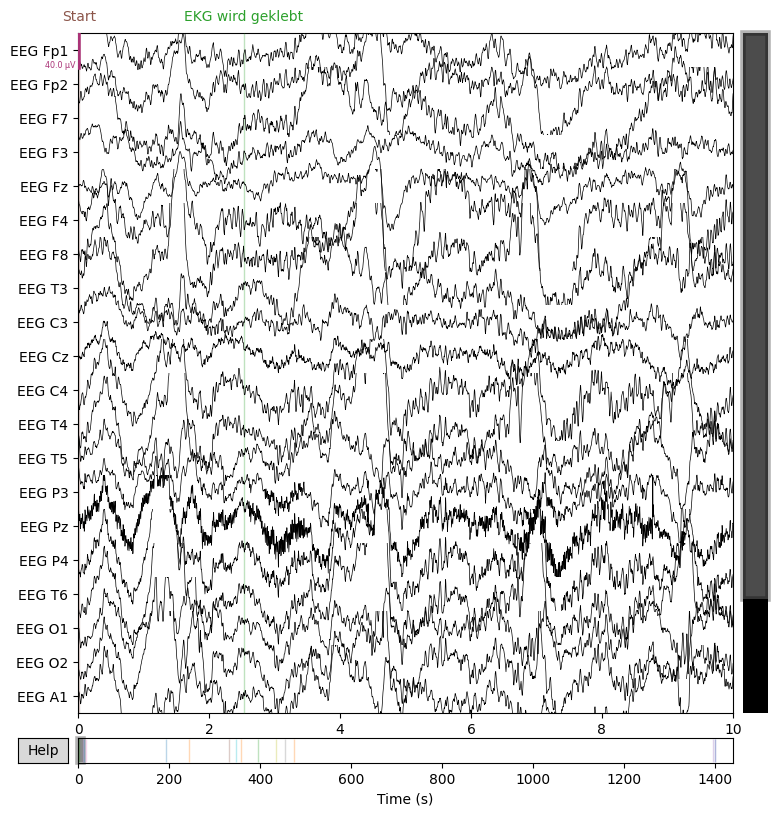

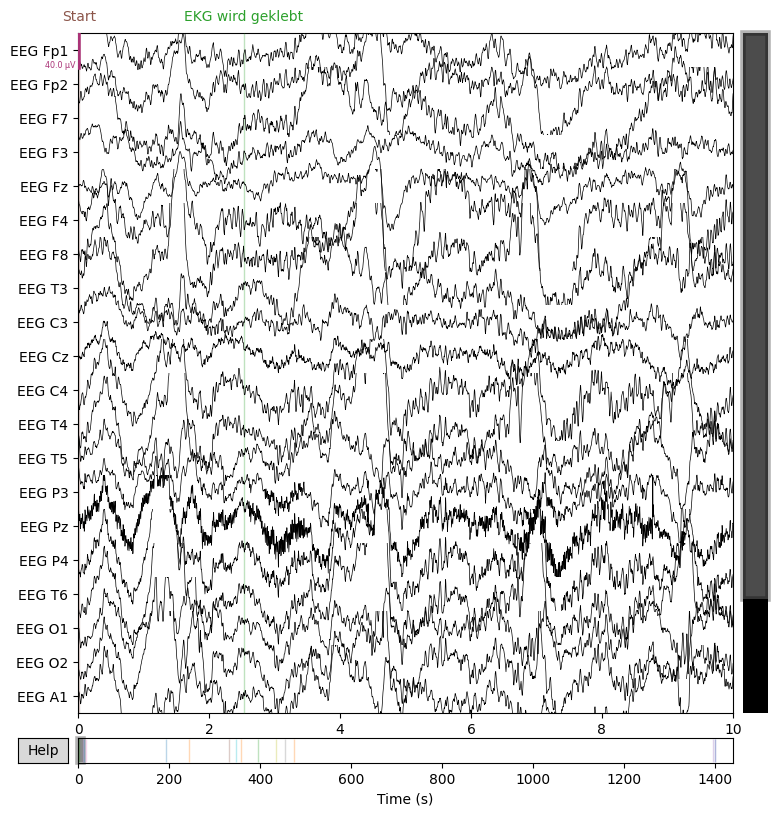

In [9]:
# Plot the raw EEG data
raw.plot()

#### Plot EEG data with Matplotlib

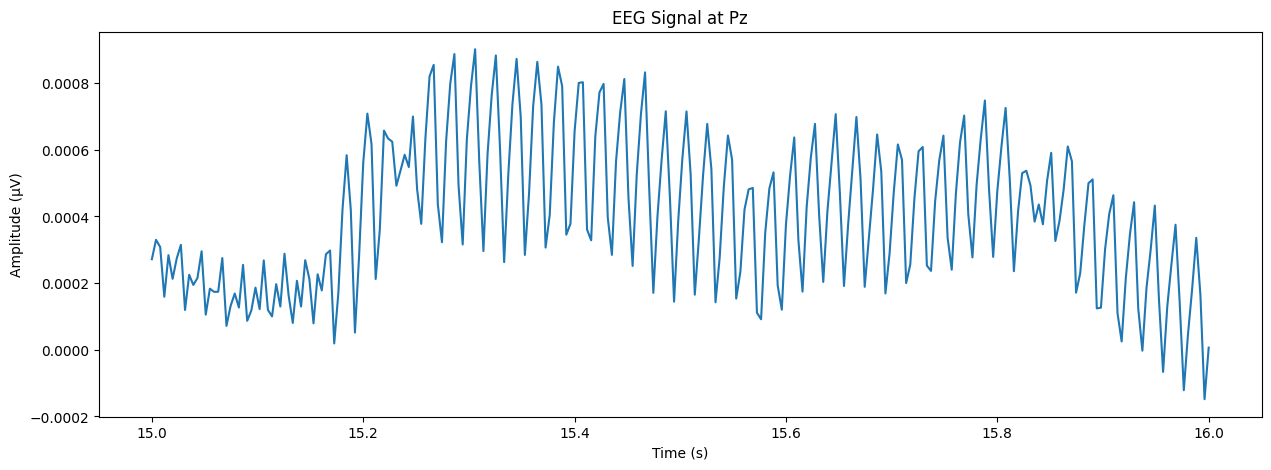

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline
# Plotting a single channel
fig, ax = plt.subplots(figsize=[15, 5])

start_time = 15
end_time = 16
# Get the data from channel Pz, from 1500 - 1600 ms
data = raw.get_data(picks='EEG Pz',tmin=start_time, tmax=end_time).T
# Get the time values
times = np.linspace(start_time, end_time, num=data.shape[0])

ax.plot(times, data)
ax.set_title('EEG Signal at Pz')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (μV)')
plt.show()


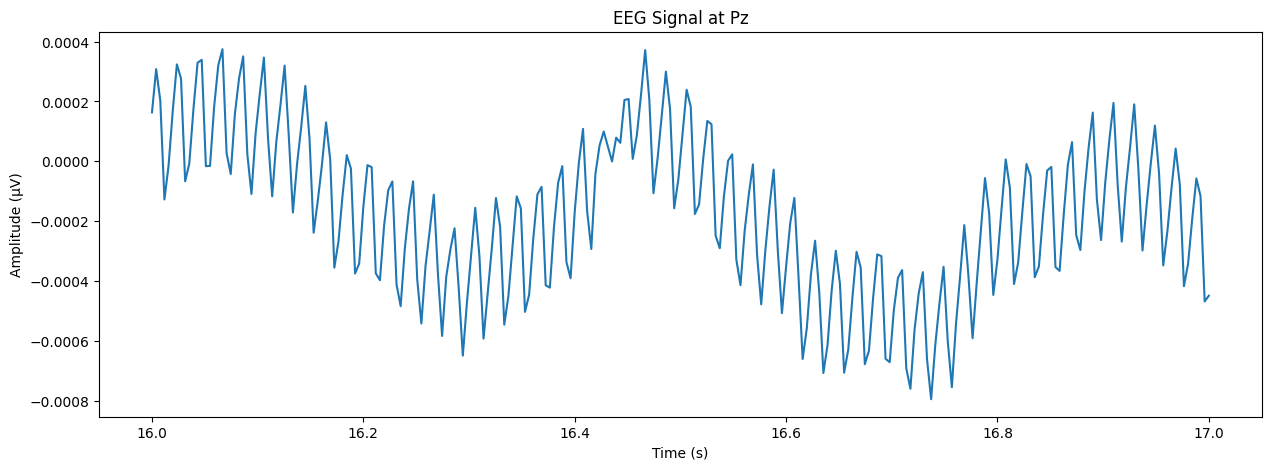

In [11]:
# Plotting a single channel
fig, ax = plt.subplots(figsize=[15, 5])

start_time = 16
end_time = 17
# Get the data from channel Pz, from 1600 - 1700 ms
data = raw.get_data(picks='EEG Pz',tmin=start_time, tmax=end_time).T
# Get the time values
times = np.linspace(start_time, end_time, num=data.shape[0])

ax.plot(times, data)
ax.set_title('EEG Signal at Pz')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (μV)')
plt.show()

### Filtering

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz



FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 845 samples (3.301 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


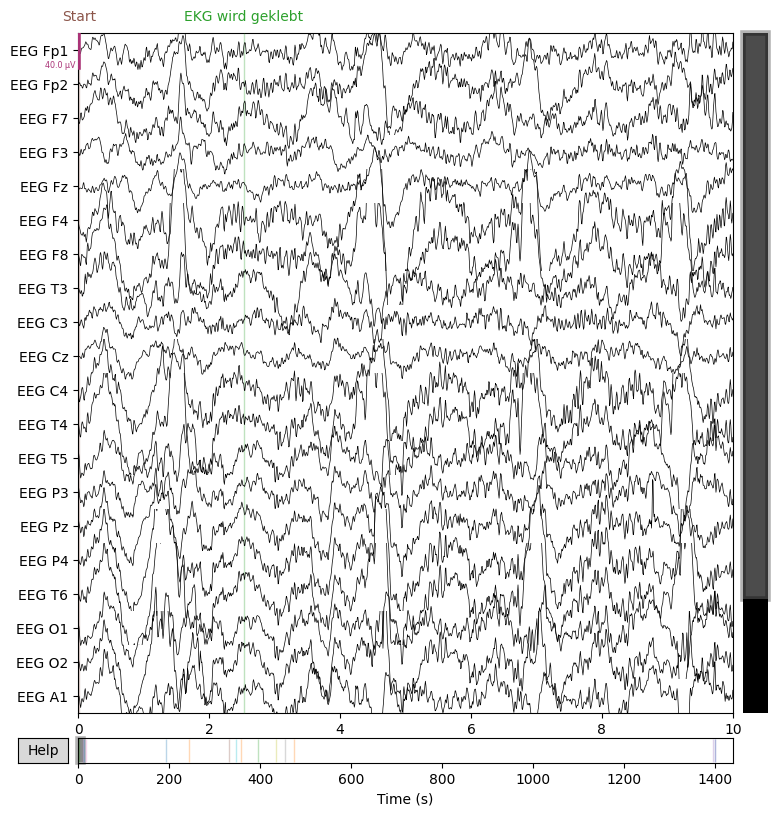

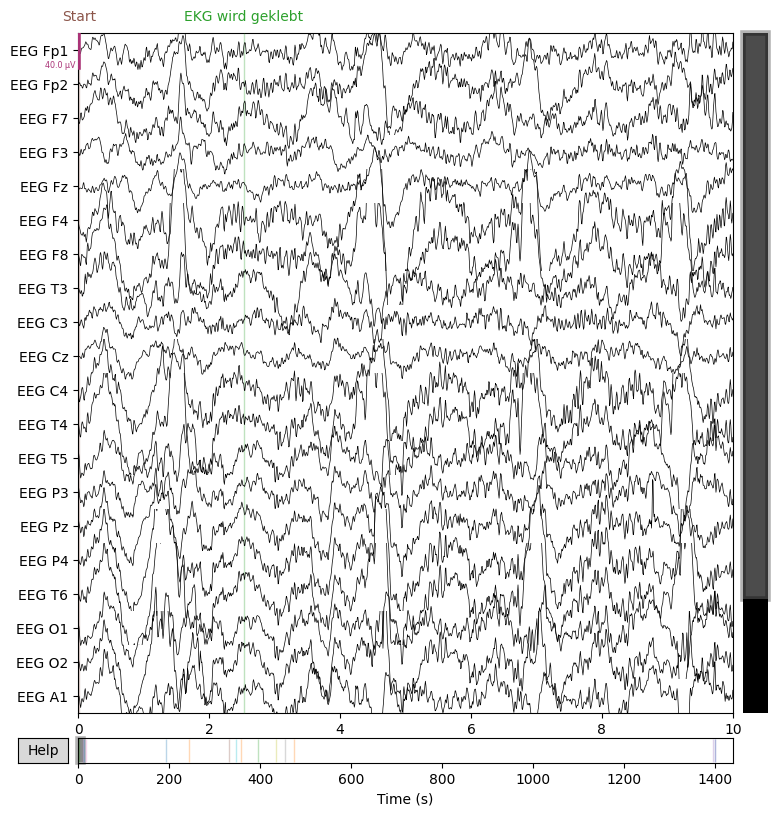

In [12]:
raw_filtered = raw.filter(1, 40)
raw_filtered.plot()

#### Single channel filtered

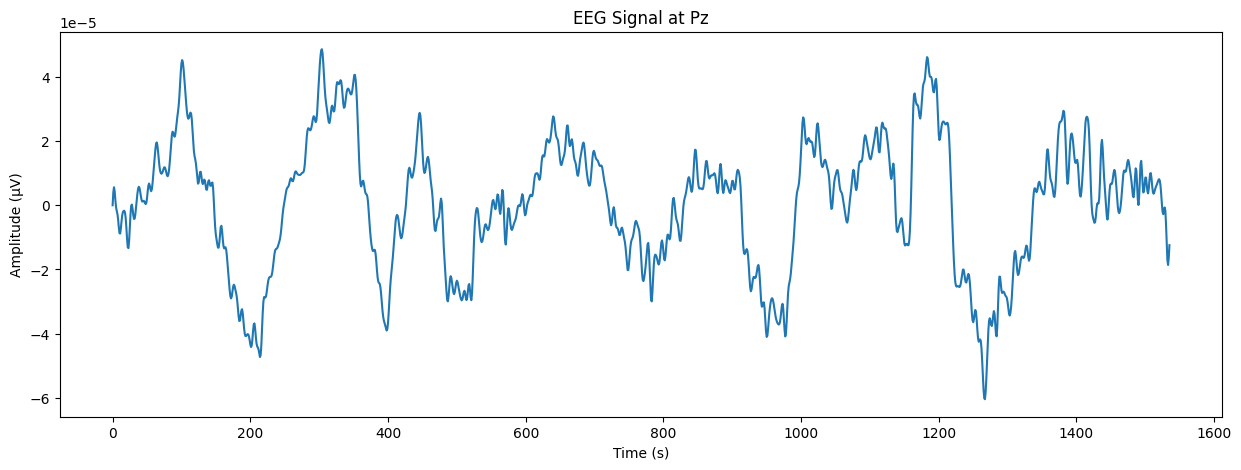

In [13]:
# Plotting a single (filterd) channel
fig, ax = plt.subplots(figsize=[15, 5])

start_time = 0
end_time = 6

ax.plot(raw_filtered.get_data(picks='EEG Pz',tmin=start_time, tmax=end_time).T)
ax.set_title('EEG Signal at Pz')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (μV)')
plt.show()

In [14]:
def plot_eeg_signal(raw, channel, start_time, end_time, title=None, filtered=False):
    """
    Plot EEG signal from a specific channel.

    Parameters:
    raw (mne.io.Raw): Raw EEG data.
    channel (str): Channel name (e.g. 'EEG Pz').
    start_time (float): Start time of the plot in seconds.
    end_time (float): End time of the plot in seconds.
    title (str, optional): Plot title. Defaults to None.
    filtered (bool, optional): Whether to use filtered data. Defaults to False.
    """
    fig, ax = plt.subplots(figsize=[15, 5])

    if filtered:
        data = raw.filter(1, 40).get_data(picks=channel, tmin=start_time, tmax=end_time).T
    else:
        data = raw.get_data(picks=channel, tmin=start_time, tmax=end_time).T

    ax.plot(data)
    ax.set_title(title or f'EEG Signal at {channel}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude (μV)')
    plt.show()

#### View EEG channel unfiltered vs. filtered 

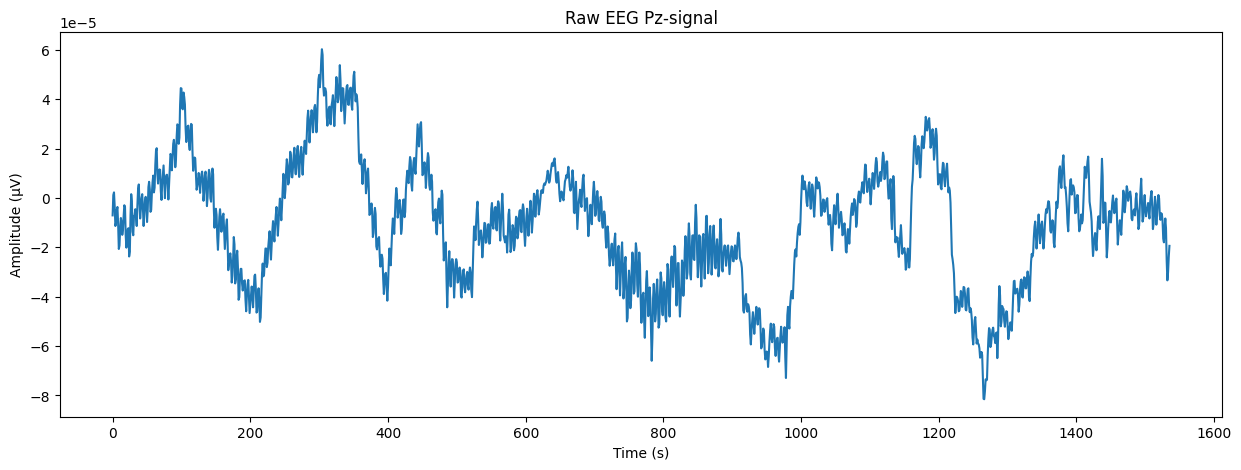

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 845 samples (3.301 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


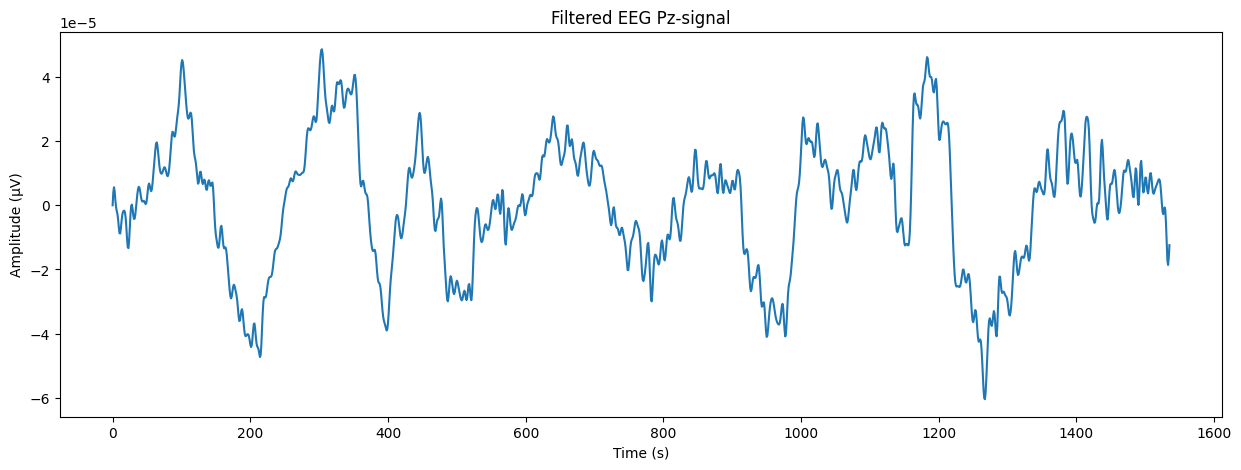

In [15]:
# View the first 15 mins of raw and filtered data
plot_eeg_signal(original_raw, 'EEG Pz',0, 6, title='Raw EEG Pz-signal', filtered=False)
plot_eeg_signal(original_raw, 'EEG Pz', 0, 6, title='Filtered EEG Pz-signal', filtered=True)

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_brain_data(brain_data, cmap='viridis'):
  """
  Visualizes brain data as a matrix of circles, with each circle's color 
  representing the intensity of the data point.

  Args:
    brain_data: A 2D numpy array containing the brain data.
    cmap: The colormap to use for the visualization. 
          See matplotlib's documentation for available colormaps.
  """

  num_rows, num_cols = brain_data.shape
  fig, ax = plt.subplots(figsize=(num_cols/10, num_rows/10))

  # Hide axes
  ax.axis('off')

  for row in range(num_rows):
    for col in range(num_cols):
      circle = plt.Circle((col, row), 0.4, color=plt.cm.get_cmap(cmap)(brain_data[row, col]))
      ax.add_artist(circle)

  ax.set_aspect('equal')
  ax.autoscale_view()
  plt.show()

# Example usage with single EEG file:
data = data.copy()

visualize_brain_data(data, cmap='magma')

C:\Users\c_arz\AppData\Local\Temp\ipykernel_9992\3663680225.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  circle = plt.Circle((col, row), 0.4, color=plt.cm.get_cmap(cmap)(brain_data[row, col]))


### TO DO

- Loading data by creating _patient_data_ dictionary as in '01_clustering_algo_all' notebook

In [17]:
data_files = sorted(list(RAW_KISPI_DATA_FOLDER.glob('*.edf')))

In [18]:
patient_data = {}

for file in tqdm.tqdm(data_files):
    patient_id = file.stem.split("_")[0]
    data = mne.io.read_raw_edf(file)
    
    fs = data.loc[patient_id, "sample_rate"]
    patient_data[patient_id] = {'data': data, 'fs': fs}

NameError: name 'tqdm' is not defined